In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt

In [2]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 5

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train Samples:", len(train_dataset))
print("Test Samples:", len(test_dataset))

100.0%
100.0%
100.0%
100.0%

Train Samples: 60000
Test Samples: 10000


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

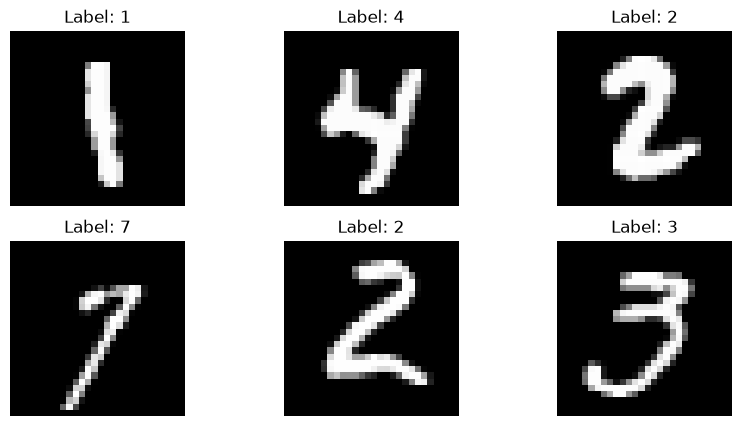

In [6]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(f"Label: {labels[i]}")
    plt.axis("off")

plt.show()

In [7]:
class FCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [8]:
def train_model(model, loader):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    model.train()

    for epoch in range(EPOCHS):

        running_loss = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(
            f"Epoch {epoch+1}/{EPOCHS} "
            f"Loss: {running_loss/len(loader):.4f}"
        )

In [9]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return 100 * correct / total

In [10]:
baseline_model = FCNN().to(device)

train_model(
    baseline_model,
    train_loader
)

Epoch 1/5 Loss: 0.2746
Epoch 2/5 Loss: 0.1021
Epoch 3/5 Loss: 0.0650
Epoch 4/5 Loss: 0.0487
Epoch 5/5 Loss: 0.0361


In [11]:
baseline_accuracy = evaluate_model(
    baseline_model,
    test_loader
)

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy:.2f}%"
)

Baseline Accuracy: 97.69%


In [27]:
test_iter = iter(test_loader)

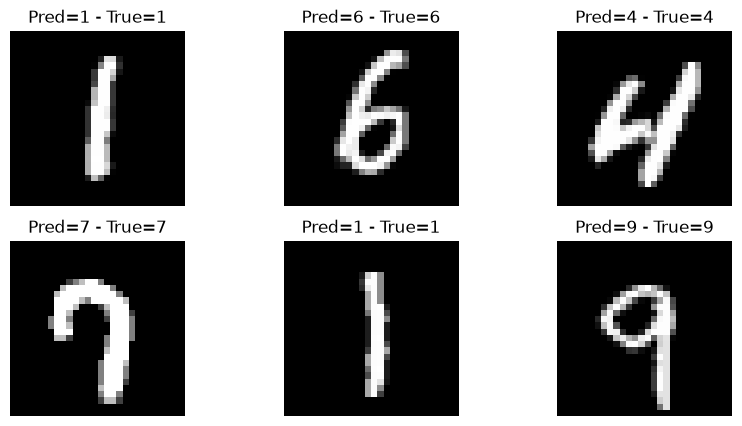

In [40]:
baseline_model.eval()

images, labels = next(test_iter)

with torch.no_grad():

    outputs = baseline_model(
        images.to(device)
    )

    predictions = outputs.argmax(dim=1).cpu()

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Pred={predictions[i]} - True={labels[i]}"
    )

    plt.axis("off")

plt.show()

In [13]:
perm = torch.randperm(784)

print(perm[:20])

tensor([591, 737,  48, 616, 390, 248,  72, 560, 571, 125, 572, 774, 118, 284,
        418, 332, 278, 293, 705, 411])


In [14]:
class ShuffledMNIST(Dataset):

    def __init__(
        self,
        dataset,
        permutation
    ):

        self.dataset = dataset
        self.permutation = permutation

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, label = self.dataset[idx]

        image = image.view(-1)

        image = image[
            self.permutation
        ]

        image = image.view(
            1,
            28,
            28
        )

        return image, label

In [15]:
shuffled_train_dataset = ShuffledMNIST(
    train_dataset,
    perm
)

shuffled_test_dataset = ShuffledMNIST(
    test_dataset,
    perm
)

In [16]:
shuffled_train_loader = DataLoader(
    shuffled_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

shuffled_test_loader = DataLoader(
    shuffled_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

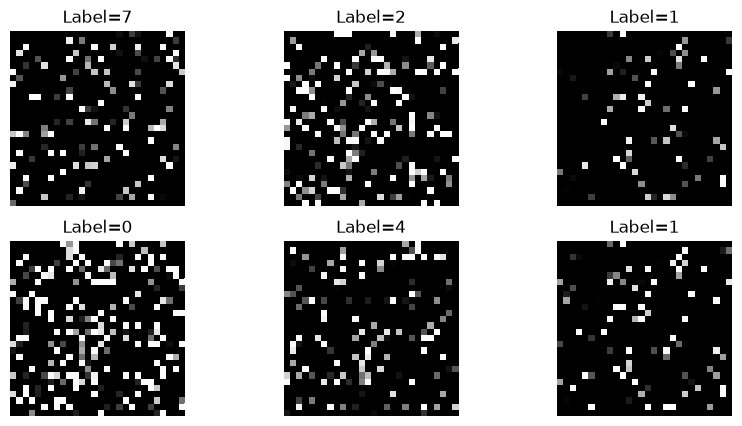

In [17]:
images, labels = next(
    iter(shuffled_test_loader)
)

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Label={labels[i]}"
    )

    plt.axis("off")

plt.show()

In [19]:
shuffled_model = FCNN().to(device)

train_model(
    shuffled_model,
    shuffled_train_loader
)

Epoch 1/5 Loss: 0.2824
Epoch 2/5 Loss: 0.1114
Epoch 3/5 Loss: 0.0718
Epoch 4/5 Loss: 0.0501
Epoch 5/5 Loss: 0.0401


In [20]:
shuffled_accuracy = evaluate_model(
    shuffled_model,
    shuffled_test_loader
)

print(
    f"Shuffled Accuracy: "
    f"{shuffled_accuracy:.2f}%"
)

Shuffled Accuracy: 97.69%


In [21]:
print("=" * 40)

print(
    f"Original Accuracy : "
    f"{baseline_accuracy:.2f}%"
)

print(
    f"Shuffled Accuracy : "
    f"{shuffled_accuracy:.2f}%"
)

print("=" * 40)

Original Accuracy : 97.69%
Shuffled Accuracy : 97.69%


In [22]:
print("""
Baseline Accuracy:
The model achieved high accuracy on original MNIST.

Shuffled Accuracy:
Accuracy decreased slightly after pixel shuffling.

Visual Difference:
Original images are recognizable while shuffled images look like noise.

Explanation:
A fully connected network does not explicitly use image spatial structure.
Since the same permutation is applied to all images, the network can still learn patterns.

Key Takeaway:
Humans rely on image structure, while a fully connected network can learn
from consistent pixel relationships even after shuffling.
""")


Baseline Accuracy:
The model achieved high accuracy on original MNIST.

Shuffled Accuracy:
Accuracy decreased slightly after pixel shuffling.

Visual Difference:
Original images are recognizable while shuffled images look like noise.

Explanation:
A fully connected network does not explicitly use image spatial structure.
Since the same permutation is applied to all images, the network can still learn patterns.

Key Takeaway:
Humans rely on image structure, while a fully connected network can learn
from consistent pixel relationships even after shuffling.

